In [1]:
import os
import mat73
import pandas as pd
import numpy as np
import sys
import json
import pickle
sys.path.append("..")
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import matplotlib.colors as mcolors
from scipy.spatial import cKDTree
import scipy
from nilearn import plotting
from src.decomposition import CompoThr
from src.setting import GetInfo, PROJECT_PATH
from src.config import COL_REG, col_pc

from scipy.linalg import subspace_angles
from scipy.stats import spearmanr
import nibabel as nib
from nilearn import datasets
from nilearn.image import load_img
from sklearn.manifold import Isomap, LocallyLinearEmbedding, MDS, SpectralEmbedding, TSNE


In [2]:
ieeg_datapath = 'ieeg_shortWOBS_fs250'
meg_datapath = '/projects/MINDLAB2025_MEG-Auditory_Cognitive_Maps/scratch/APR2020_Block3_SingleTrial_BarbaraNikita'
meg_outpath ='MEG/dataMEG'

os.path.isdir(meg_datapath)
#meg_subj_list = [file.replace('_norm0_abs_0.mat', '') for file in os.listdir(meg_datapath) if 'SUBJ' in file]
meg_subj_list = [file.replace('_sensor.p', '') for file in os.listdir(meg_outpath) if '_sensor' in file]
print('MEG Subject number : ', len(meg_subj_list))

#for subj in meg_subj_list[:1] : 
#    subj_mat =  mat73.loadmat(meg_datapath + '/' + subj + '_norm0_abs_0.mat')
#    time_meg = subj_mat['OUT']['time'] # 1026
#    del subj_mat

ieeg_subj_list = [file.replace('_epochs.p', '') for file in os.listdir(ieeg_datapath) if file[-len('epochs.p'):] == 'epochs.p']
print('iEEG Subject number : ', len(ieeg_subj_list))

info_file = ieeg_datapath + f'/{ieeg_subj_list[0]}_info.json'
with open(info_file) as json_data:
    d = json.load(json_data)
    time_ieeg = d['time_epoch']

project_path = '../' + PROJECT_PATH
coord, areas, elect_list, subj_list, regions_ieeg = GetInfo(ieeg_subj_list, data_path=ieeg_datapath, project_path=project_path)
coord=np.array(coord)
coord = np.where(abs(coord) >100, coord/1000, coord)
coord = np.where(abs(coord) >100, coord/1000, coord)
coord = coord/1000

MEG Subject number :  32
iEEG Subject number :  30


In [3]:
from utils import match_meg, mask_meg, get_region_label
color_=['darkblue', 'orange', 'green']
r=5

## Get data

In [4]:
from utils import get_meg_data, get_ieeg_data
ieeg_data_mean = get_ieeg_data(ieeg_datapath, ieeg_subj_list)*1000 # As there is a /1000 in the normalisation function of the ieEG preproc -- To remove 
meg_data_source = get_meg_data(meg_outpath, meg_subj_list)

In [5]:
data_masked = mask_meg(meg_data_source, coord, radius_1=r, show=False).mean(0)
data_matched = match_meg(meg_data_source, ieeg_subj_list, coord, meg_subj_list, subj_list)
data_matched_average = match_meg(meg_data_source, ieeg_subj_list, coord, meg_subj_list, subj_list, average_subject=True)

In [6]:
file = 'out/data/trans_meg_concat.p'
with open(file, "rb") as f:
    trans_meg_concat = pickle.load(f)

file = 'out/data/expl_var_meg_concat.p'
with open(file, "rb") as f:
    expl_var_meg_concat = pickle.load(f)

## Compare coverage

In [14]:
# run PCA to evalute the effect of the mask
pca_source = PCA(10)
#meg_trans = pca_source.fit_transform(np.concat([meg_data_source.mean(1)[i, :, :] for i in range(meg_data_source.shape[0])]).T) 
meg_trans = pca_source.fit_transform(meg_data_source.mean(0).mean(0).T)
pca_masked = PCA(10)
meg_mask_trans = pca_masked.fit_transform(data_masked.mean(0).T) 
pca_matched = PCA(10)
meg_match_trans = pca_matched.fit_transform(data_matched.mean(0).T) 

In [15]:
pca_matched_avg = PCA(10)
matched_avg_trans = pca_matched_avg.fit_transform(data_matched_average.mean(0).T) 

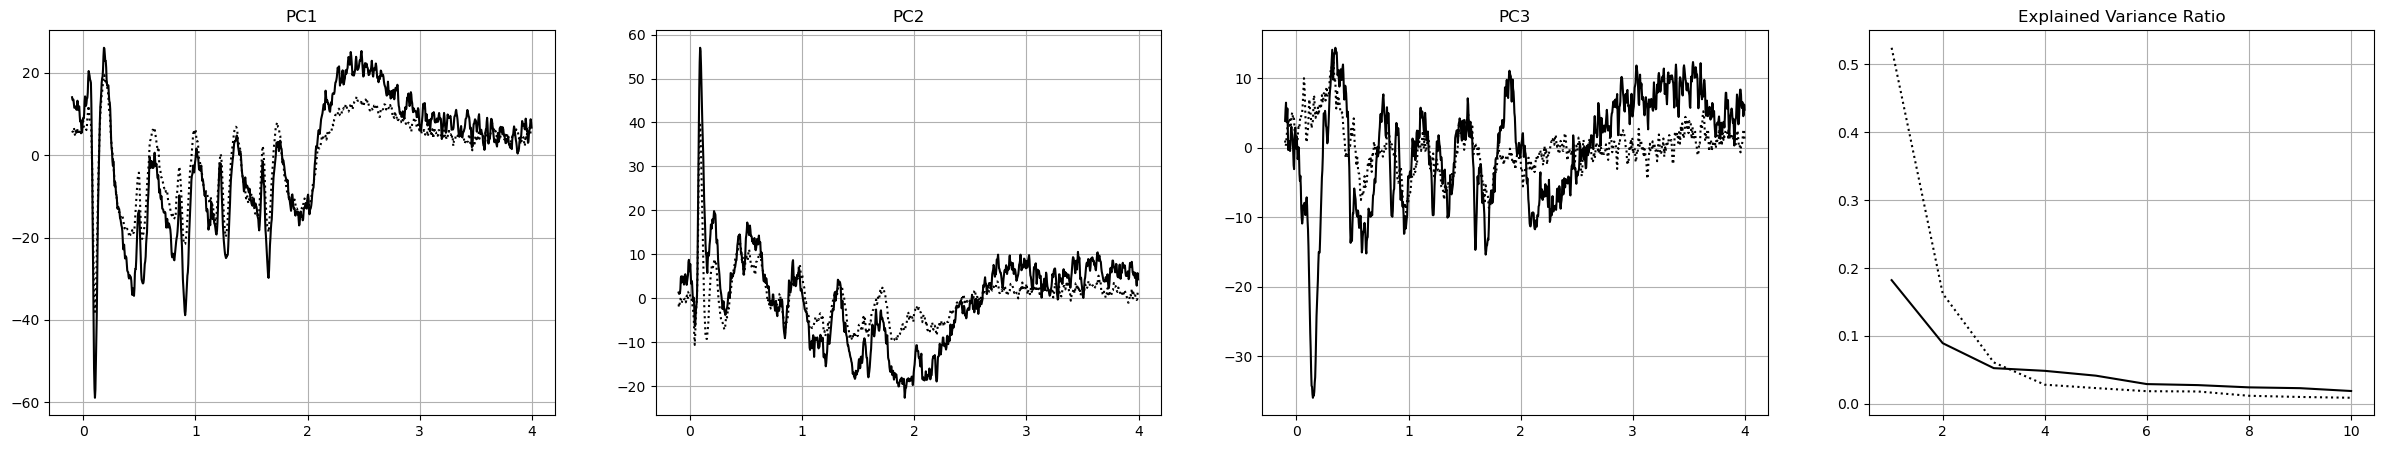

In [16]:
fig, ax=plt.subplots(1, 4, figsize=(30, 5))
pca_source = PCA(10)
meg_trans = pca_source.fit_transform(meg_data_source.mean(0).mean(0).T)

meg_trans[:, 1] = - meg_trans[:, 1]
#meg_trans[:, 0] = - meg_trans[:, 0]

for j in range(3):
    ax[j].plot(time_ieeg, meg_trans[:, j], c='k', ls=':')
    ax[j].plot(time_ieeg, matched_avg_trans[:, j], c='k') # matched_avg_trans
    ax[j].grid()
    ax[j].set_title('PC' + str(j+1))

ax[3].plot(np.arange(1, 11, 1), pca_source.explained_variance_ratio_, c='k', ls=':')
ax[3].plot(np.arange(1,11,1), pca_matched_avg.explained_variance_ratio_, c='k')
#ax[3].plot(np.arange(1,11,1),expl_var_meg_concat, c='k')

ax[3].set_title('Explained Variance Ratio')
    
ax[3].grid()

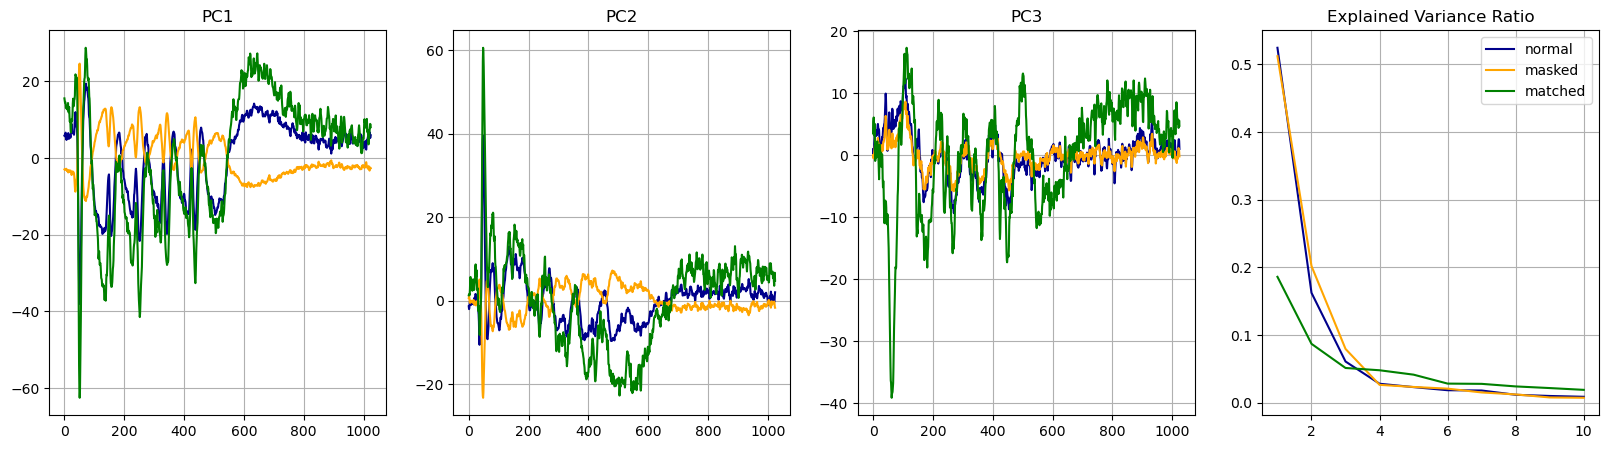

In [17]:
fig, ax=plt.subplots(1, 4, figsize=(20, 5))
names=['normal', 'masked', 'matched']

for i, meg_d in enumerate([meg_trans, meg_mask_trans, meg_match_trans]) :
    for j in range(3):
        ax[j].plot(meg_d[:, j], c=color_[i],label=names[i])
        ax[j].grid()
        ax[j].set_title('PC' + str(j+1))

for i, pc in enumerate([pca_source, pca_masked, pca_matched]) : 
    ax[3].plot(np.arange(1, 11, 1), pc.explained_variance_ratio_, label=names[i], c=color_[i])
ax[3].set_title('Explained Variance Ratio')
    
ax[3].legend()
ax[3].grid()

### Get the regions

In [18]:
pos = pd.read_csv('/users/barbara/Desktop/MIB_iEEG/iEEGvsMEG/MEG/dataMEG/SUBJ_0002_pos.csv').drop(columns='Unnamed: 0')
mask = mask_meg(pos, coord, radius_1=r, return_mask=True, show=False) # mask area not covered
pos_m = pos[mask] 
pos_match=[]

mask_match = match_meg(meg_data_source, ieeg_subj_list, coord, meg_subj_list, subj_list, return_mask=True )
for s in mask_match.keys() : 
    pos_s = pd.read_csv(f'/users/barbara/Desktop/MIB_iEEG/iEEGvsMEG/MEG/dataMEG/{s}_pos.csv').drop(columns='Unnamed: 0')
    pos_match.append(pos_s.loc[mask_match[s], :])
pos_match = pd.concat(pos_match)

regions_meg_m = get_region_label(pos_m)
regions_meg = get_region_label(pos)
regions_meg_match=get_region_label(pos_match)

all_regions = sorted(set(regions_meg) | set(regions_ieeg))
used_colors = {c.lower() for c in COL_REG.values()}
cmap = plt.get_cmap("tab20", max(20, len(all_regions)))

color_idx = 0
for region in all_regions:
    if region not in COL_REG:
        while True:
            color = mcolors.to_hex(cmap(color_idx))
            color_idx += 1
            if color.lower() not in used_colors:
                break

        COL_REG[region] = color
        used_colors.add(color.lower())


[fetch_atlas_aal] Dataset found in /users/barbara/nilearn_data/aal_SPM12

[fetch_atlas_aal] Dataset found in /users/barbara/nilearn_data/aal_SPM12

[fetch_atlas_aal] Dataset found in /users/barbara/nilearn_data/aal_SPM12

(np.float64(-0.1), np.float64(1.0), np.float64(-28.0), np.float64(1.0))

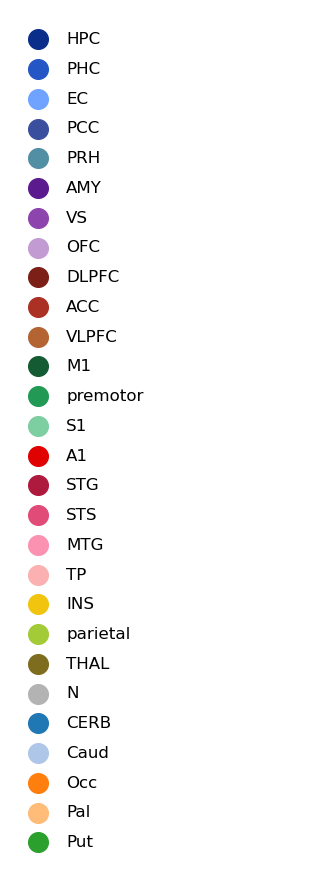

In [19]:
fig, ax = plt.subplots(figsize=(4, len(COL_REG) * 0.4))

for i, (region, color) in enumerate(COL_REG.items()):
    ax.scatter(0, -i, s=200, color=color)
    ax.text(0.1, -i, region, va='center', fontsize=12)

ax.set_xlim(-0.1, 1)
ax.set_ylim(-len(COL_REG), 1)
ax.axis('off')

In [20]:
all_regions = sorted(set(regions_meg) | set(regions_meg_m) | set(regions_meg_match))
region_order = list(COL_REG.keys())

### diff of coverage

In [21]:
reg_meg, count_reg_meg = np.unique(regions_meg, return_counts=True)
reg_ieeg, count_reg_ieeg = np.unique(regions_ieeg, return_counts=True)

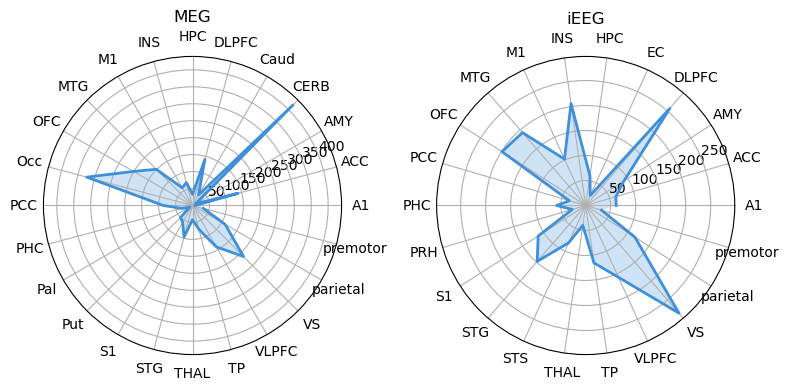

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(8, 8), subplot_kw={"projection": "polar"})

for i, (a, c) in enumerate(zip([reg_meg, reg_ieeg], [count_reg_meg, count_reg_ieeg])) : 
    id_to_keep = np.where(a != 'N')
    a=a[id_to_keep]
    c = c[id_to_keep]

    angles = np.linspace(0, 2*np.pi, len(a), endpoint=False)

    ax[i].plot(angles, c, linewidth=2)
    ax[i].fill(angles,c, alpha=0.25)
    ax[i].set_xticks(angles)
    ax[i].set_xticklabels(a)

ax[0].set_title('MEG')
ax[1].set_title('iEEG')

plt.tight_layout()

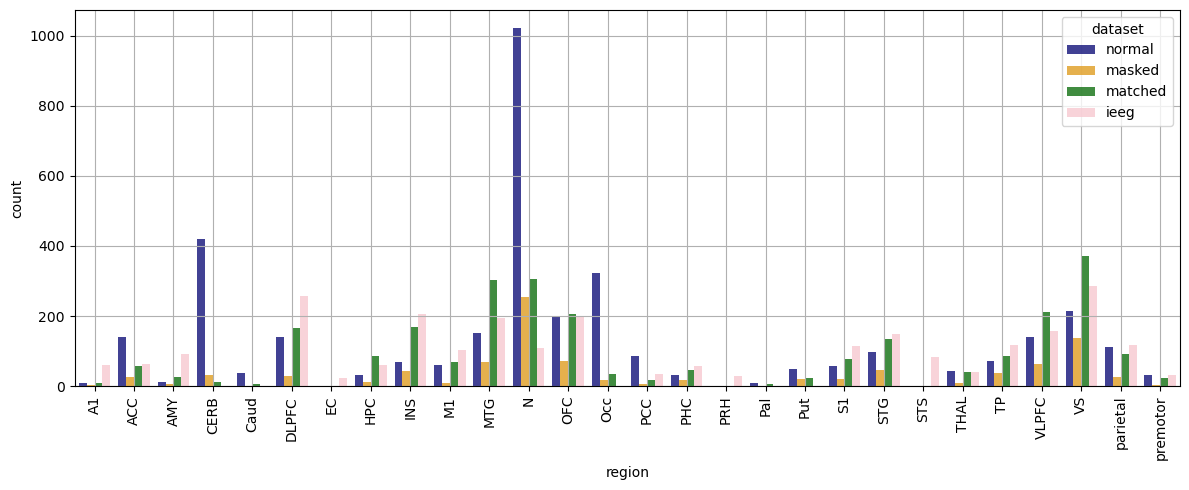

In [23]:
df = pd.DataFrame({'region': np.unique(regions_meg + regions_meg_m + regions_meg_match + regions_ieeg)})
names=['normal', 'masked', 'matched', 'ieeg']
color_=['darkblue', 'orange', 'green', 'pink']
for i in range(4):
    df[f'count_{i}'] = 0
for ir, region_list in enumerate([regions_meg, regions_meg_m, regions_meg_match, regions_ieeg]):
    regions, counts = np.unique(region_list, return_counts=True)
    df.loc[df['region'].isin(regions), f'count_{ir}'] = (df.loc[df['region'].isin(regions), 'region'].map(dict(zip(regions, counts))))

df_long = df.melt(id_vars='region',value_vars=[f'count_{i}' for i in range(4)],var_name='dataset',value_name='count')
df_long['dataset'] = df_long['dataset'].map({o : n for o, n in zip([f'count_{i}' for i in range(4)], names)})
color_palette = {n : c for n, c in zip(names, color_)}

plt.figure(figsize=(12, 5))
sns.barplot(data=df_long,x='region',y='count',hue='dataset',palette=color_palette, alpha = 0.8)

plt.xticks(rotation=90)
plt.tight_layout()
plt.grid()
plt.show()


### PCA spatial orga


In [24]:
compo_thr_m = CompoThr(pca_masked.components_)
compo_thr = CompoThr(pca_source.components_)
compo_thr_matched = CompoThr(pca_matched.components_)

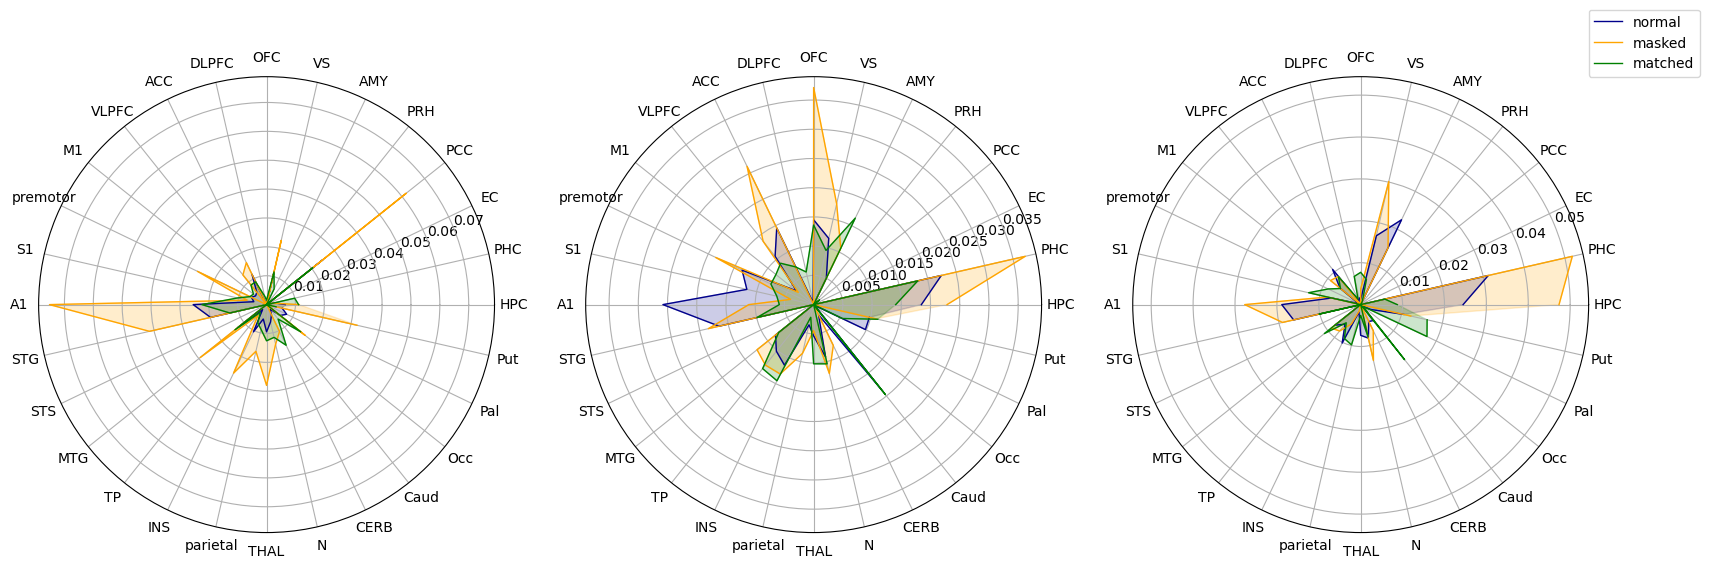

In [25]:
fig, ax = plt.subplots(1, 3, subplot_kw={"projection": "polar"}, figsize=(20, 20))
for c in range(3):
    for i, (r, compo) in enumerate(zip([regions_meg, regions_meg_m, regions_meg_match],[compo_thr, compo_thr_m, compo_thr_matched])):
        df_compo = pd.DataFrame({"regions": r,"weight": np.abs(compo[c, :])})
        mean_ = (df_compo.groupby("regions")["weight"].mean().reindex(region_order, fill_value=0).to_frame())
        angles = np.linspace(0, 2*np.pi, len(region_order), endpoint=False)
        ax[c].plot(angles,mean_["weight"].values,linewidth=1,color=color_[i],label=names[i])
        ax[c].fill(angles,mean_["weight"].values,alpha=0.2,color=color_[i],)
        ax[c].set_xticks(angles)
        ax[c].set_xticklabels(region_order, rotation=90)
        #ax[c].set_yticklabels([])

ax[c].legend(loc=(1, 1))

In [29]:
subject_to_num = {sub: i + 1 for i, sub in enumerate(np.unique(subj_list))}
subject_numbers = [subject_to_num[sub] for sub in subj_list]

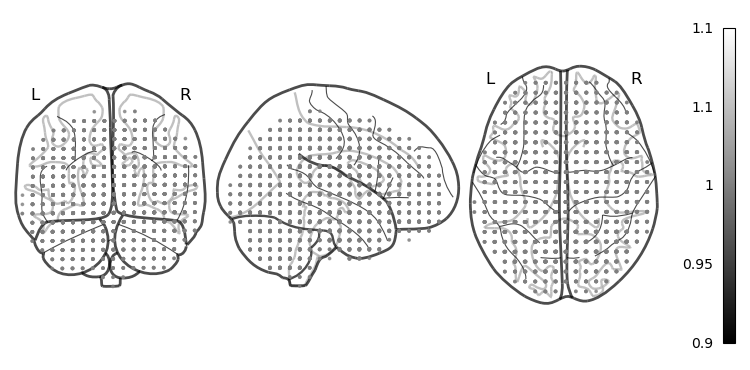

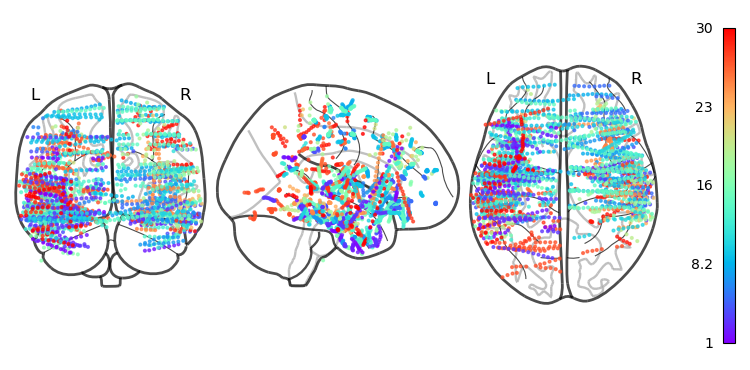

In [36]:
plotting.plot_markers(np.ones((pos.shape[0])), pos*1000, node_cmap='grey')
plotting.plot_markers(subject_numbers, coord*1000, node_cmap='rainbow')


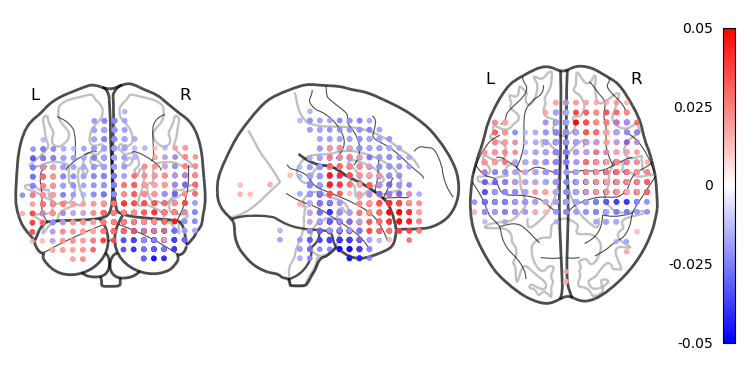

In [ ]:
mask = np.where(abs(compo_thr[1, :]) > 0, True, False)
plotting.plot_markers(compo_thr[1, mask], pos[mask]*1000, node_cmap='bwr', node_vmin=-0.05, node_vmax=0.05)

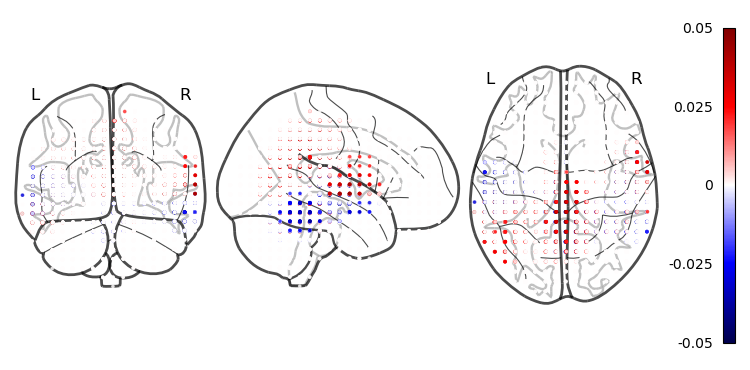

In [ ]:
plotting.plot_markers(compo_thr[0, :], pos*1000, node_cmap='seismic', node_vmin=-0.05, node_vmax=0.05)

data=compo_thr[0, :]
vmin = -np.max(np.abs(data)) 
vmax = np.max(np.abs(data))
norm_signal = (data - vmin) / (vmax - vmin)
cmap = plt.cm.seismic
colors = [tuple(cmap(val)) for val in norm_signal.flatten()]

view = plotting.view_markers(pos*1000, marker_color=colors,marker_size=5)
#view.open_in_browser()

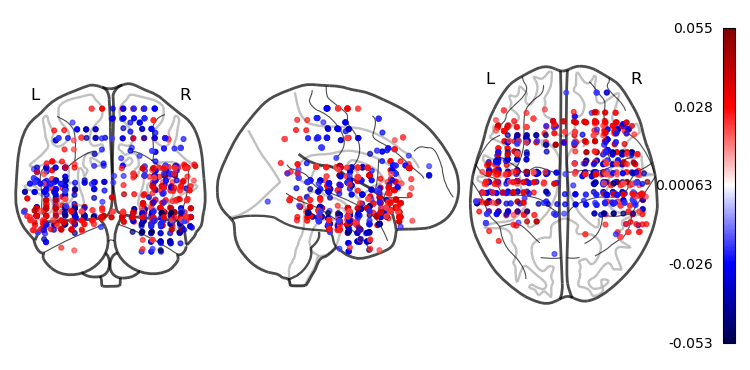

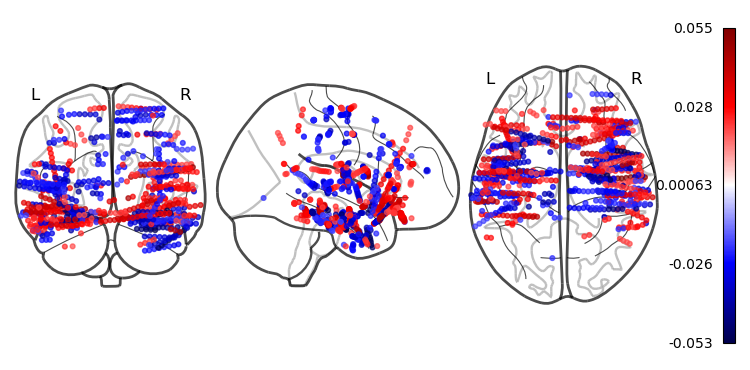

In [ ]:
mask_thr = np.where(compo_thr_matched[1, :]!=0, True, False)
plotting.plot_markers(compo_thr_matched[1, mask_thr], pos_match[mask_thr]*1000, node_cmap='seismic') #,  node_vmin=-1.1, node_vmax=1.1, node_size=5)
plotting.plot_markers(compo_thr_matched[1, mask_thr], coord[mask_thr]*1000,node_cmap='seismic') #,  node_vmin=-1.1, node_vmax=1.1, node_size=5)

### iEEG PCA

In [13]:
from src.config import col_pc

NameError: name 'region_order' is not defined

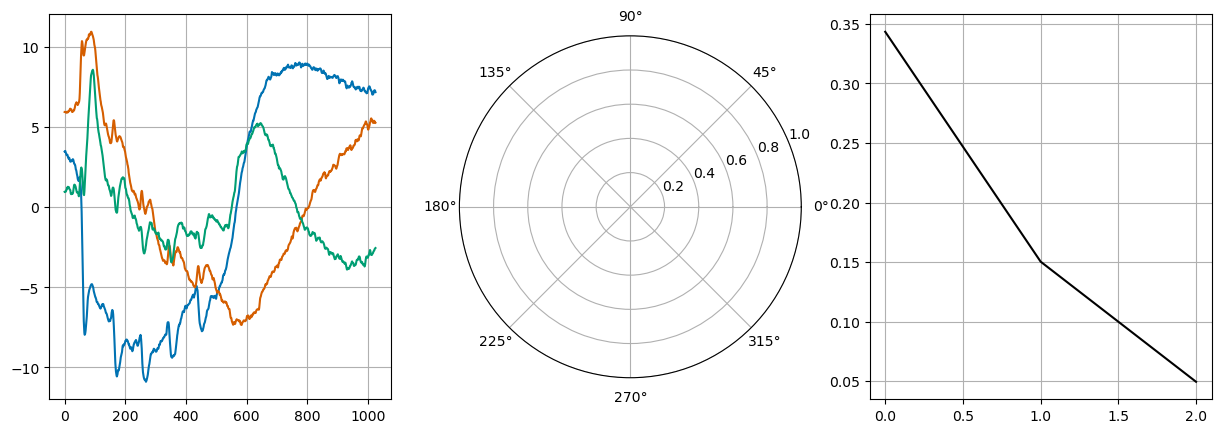

In [14]:
# Broadband ieeg
ieeg_pca = PCA(3)
trans_ieeg = ieeg_pca.fit_transform(ieeg_data_mean.mean(0).T)
fig = plt.figure(figsize=(15, 5))

ax0 = fig.add_subplot(1, 3, 1)                  # Cartesian
ax1 = fig.add_subplot(1, 3, 2, projection='polar')  # Polar
ax2 = fig.add_subplot(1, 3, 3)                  # Cartesian

for a in [ax0, ax2]:
    a.grid()

for i in range(3):
    ax0.plot(trans_ieeg[:, i], color=col_pc[i])
ax2.plot(ieeg_pca.explained_variance_ratio_, c='k')

# Component weights by region
df_compo = pd.DataFrame(np.abs(ieeg_pca.components_.T),columns=[f'PC{i+1}' for i in range(3)])
df_compo["region"] = regions_ieeg

mean_ = (df_compo.groupby("region").mean().reindex(region_order, fill_value=0))
angles = np.linspace(0, 2*np.pi, len(region_order), endpoint=False)
angles = np.r_[angles, angles[0]]

for i, col in enumerate(mean_.columns):
    values = np.r_[mean_[col].values, mean_[col].values[0]]
    ax1.plot(angles, values, label=col, color=col_pc[i])
    ax1.fill(angles, values, alpha=0.15, color=col_pc[i])

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(region_order, rotation=90)
ax1.set_yticklabels([])
ax1.legend(loc=(0.85, 1))

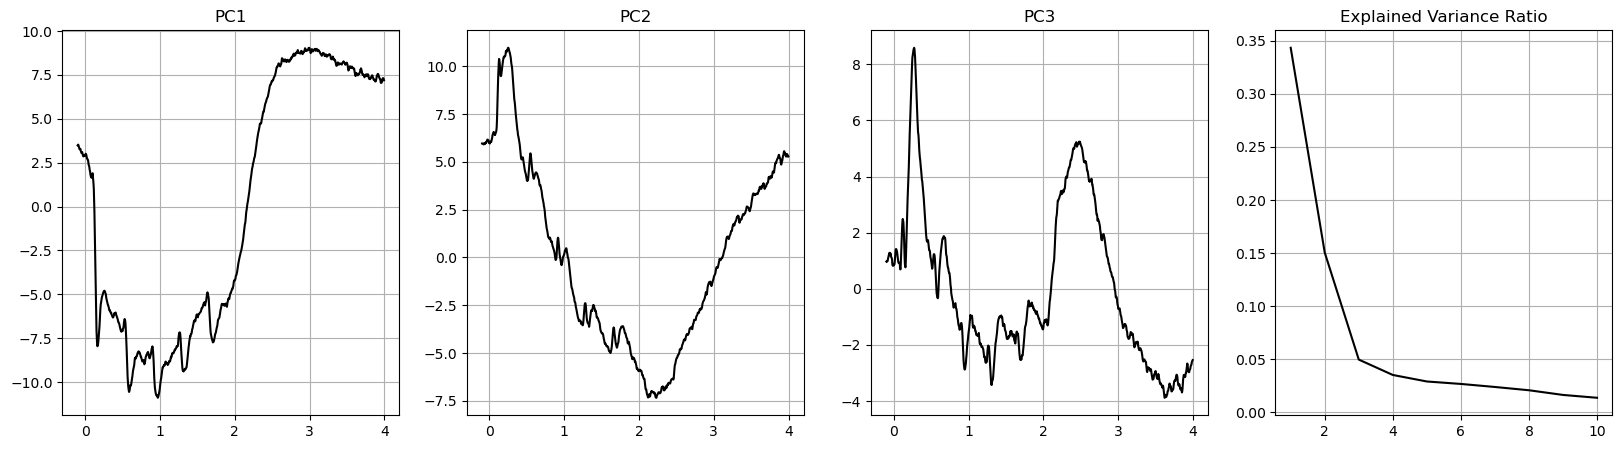

In [28]:
fig, ax=plt.subplots(1, 4, figsize=(20, 5))
ieeg_pca = PCA(10)
trans_ieeg = ieeg_pca.fit_transform(ieeg_data_mean.mean(0).T)


for j in range(3):
    ax[j].plot(time_ieeg, trans_ieeg[:, j], c='k')
    ax[j].grid()
    ax[j].set_title('PC' + str(j+1))

ax[3].plot(np.arange(1, 11, 1), ieeg_pca.explained_variance_ratio_, c='k')
ax[3].set_title('Explained Variance Ratio')
    
ax[3].grid()

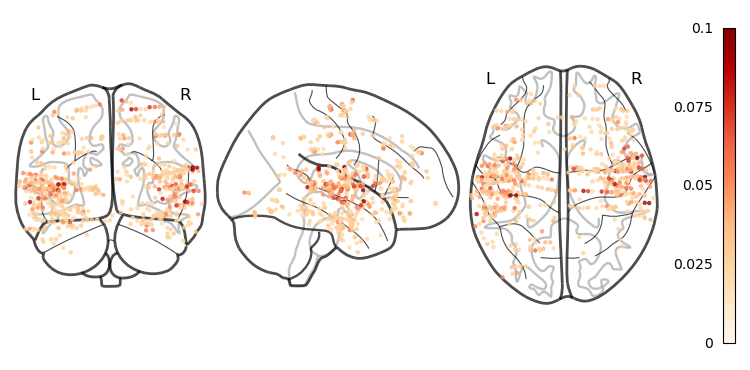

In [53]:
thr = CompoThr(ieeg_pca.components_).T
mask_thr=np.where(abs(thr[:, 2]) >0, True, False)
plotting.plot_markers(abs(thr[mask_thr, 2]), coord[mask_thr]*1000,node_cmap='OrRd', node_size=5, node_vmin=0, node_vmax=0.1)

## From many runs to confirm that matched in robust

In [55]:
# from many runs
file = 'out/meg_matched_compo_50.pkl'
with open(file, "rb") as f:
    compo = pickle.load(f)
file = 'out/meg_matched_trans_50.pkl'
with open(file, "rb") as f:
    trans = pickle.load(f)

In [59]:
pc=2

for i in range(1) : 
    compo_thr_matched = CompoThr(compo[i, :, :])
    mask_thr = np.where(compo_thr_matched[pc, :]!=0, True, False)
    plotting.plot_markers(compo_thr_matched[pc, mask_thr], pos_match[mask_thr]*1000, node_cmap='seismic') #,  node_vmin=-0.05, node_vmax=0.05, node_size=5)
plt.close()

In [57]:
col_pc= {
    0: '#0072B2',  # blue
    1: '#D55E00',  # vermillion
    2: '#009E73',  # green
    3: '#CC79A7',  # purple
    4: '#E69F00',  # orange-yellow
    5: '#56B4E9',  # sky blue
    6: '#F0E442',  # yellow
}

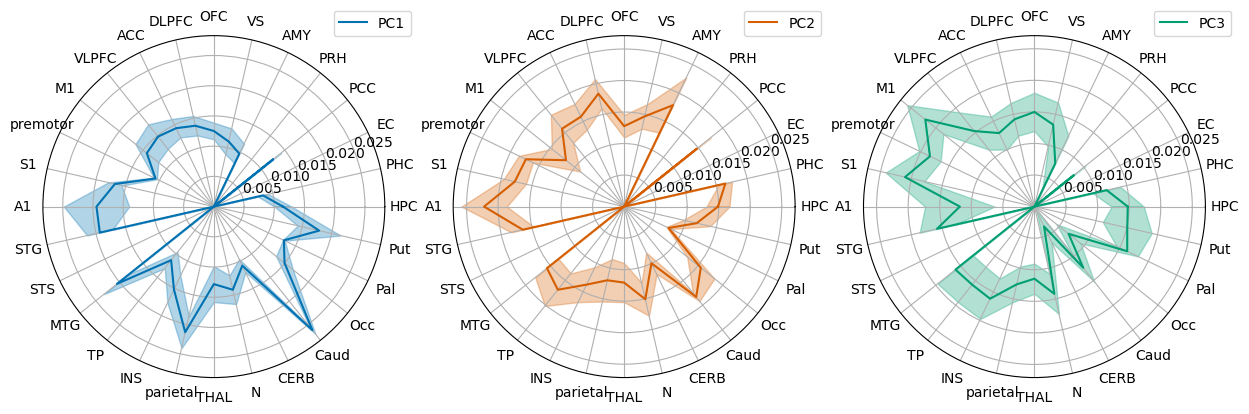

In [58]:
# Component weights by region
fig, axs = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={"projection": "polar"})

df_compo = pd.DataFrame(np.abs(compo.mean(0)).T,columns=[f'PC{i+1}' for i in range(5)])
df_compo_std = pd.DataFrame(np.abs(compo.std(0)).T,columns=[f'PC{i+1}' for i in range(5)])

df_compo["region"] = regions_meg_match #regions_ieeg
df_compo_std["region"] = regions_meg_match #regions_ieeg

mean_ = (df_compo.groupby("region").mean().reindex(region_order, fill_value=0))
std_= (df_compo_std.groupby("region").mean().reindex(region_order, fill_value=0))

angles = np.linspace(0, 2*np.pi, len(region_order), endpoint=False)
angles = np.r_[angles, angles[0]]

for i, col in enumerate(mean_.columns[:3]):
    values = np.r_[mean_[col].values, mean_[col].values[0]]
    values_std = np.r_[std_[col].values, std_[col].values[0]]
    axs[i].plot(angles, values, label=col, c=col_pc[i])
    axs[i].fill_between(angles, values - values_std,values + values_std, alpha=0.3, color=col_pc[i])

    axs[i].set_xticks(angles[:-1])
    axs[i].set_xticklabels(region_order, rotation=90)
    #axs[i].set_yticklabels([])
    axs[i].legend(loc=(0.85, 1))

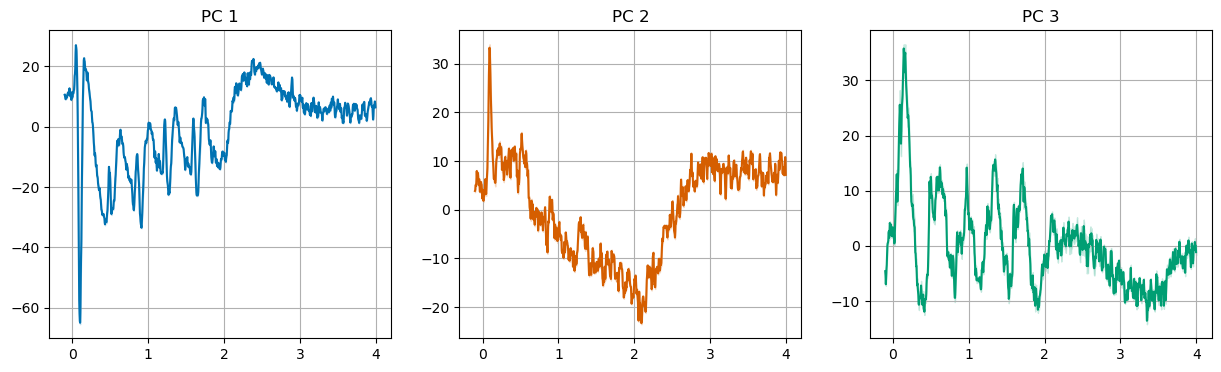

In [57]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i in range(3):
    ax[i].set_title('PC '+ str(i+1))
    ax[i].grid()
    ax[i].plot(time_ieeg, trans.mean(0)[:, i].T, c=col_pc[i])
    ax[i].fill_between(time_ieeg, trans.mean(0)[:, i].T- trans.std(0)[:, i].T, trans.mean(0)[:, i].T+ trans.std(0)[:, i].T, alpha = 0.2, color=col_pc[i])

In [59]:
# flip on PC3 poliraity based on the sign of the first pic
for r in range(50) : 
    ex_ind = np.argmax(abs(trans[r, :, 2]))
    if trans[r, ex_ind, 2] < 0 : 
        compo[r, 2,:] = - compo[r, 2,:]
        trans[r, :,2] = - trans[r,:, 2]

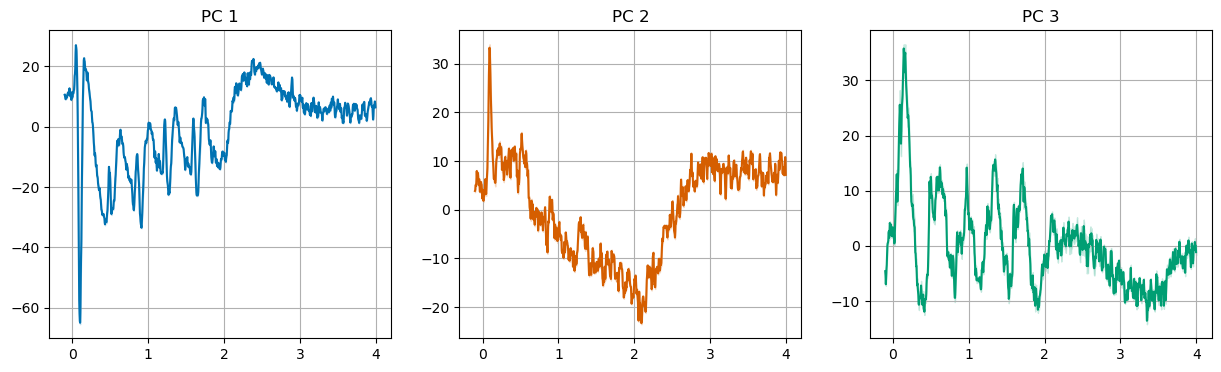

In [60]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i in range(3):
    ax[i].set_title('PC '+ str(i+1))
    ax[i].grid()
    ax[i].plot(time_ieeg, trans.mean(0)[:, i].T, c=col_pc[i])
    ax[i].fill_between(time_ieeg, trans.mean(0)[:, i].T- trans.std(0)[:, i].T, trans.mean(0)[:, i].T+ trans.std(0)[:, i].T, alpha = 0.2, color=col_pc[i])

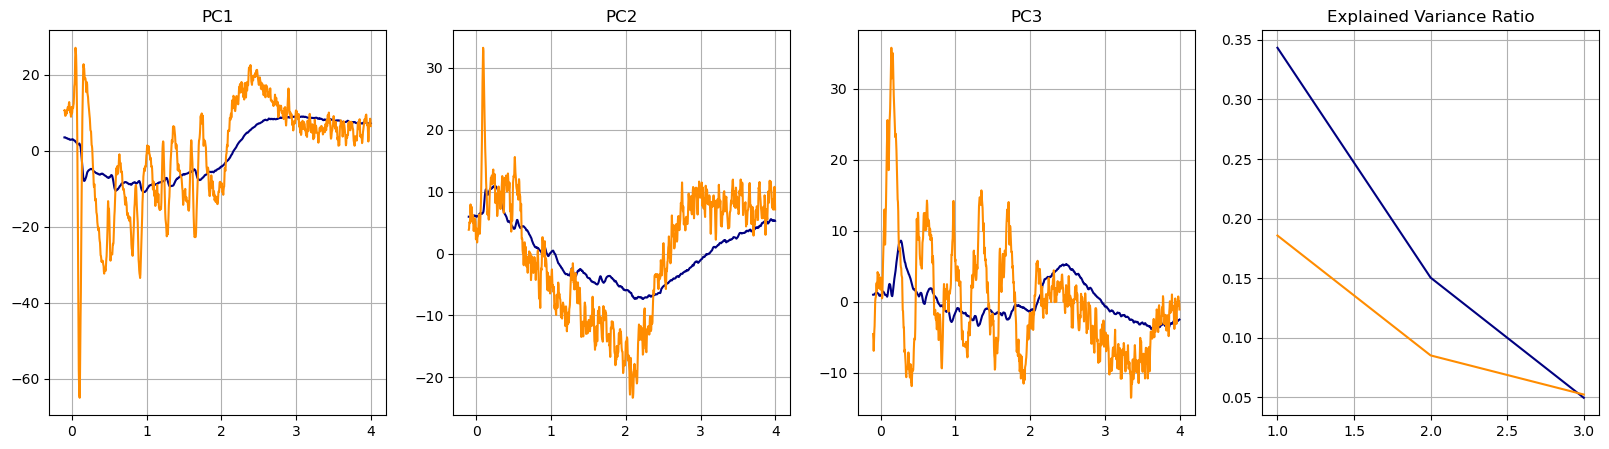

In [66]:
fig, ax=plt.subplots(1, 4, figsize=(20, 5))
ieeg_pca = PCA(10)
trans_ieeg = ieeg_pca.fit_transform(ieeg_data_mean.mean(0).T)
c_compare=['navy', 'darkorange']
lab_compare = ['ieeg', 'meg match']

for ti, t in enumerate([trans_ieeg, trans.mean(0)]):
    for j in range(3):
        ax[j].plot(time_ieeg, t[:, j], c=c_compare[ti])
        ax[j].set_title('PC' + str(j+1))

for ti, pc in enumerate([ieeg_pca,pca_matched ]) :
    ax[3].plot(np.arange(1, 4, 1), pc.explained_variance_ratio_[:3], c=c_compare[ti], label= lab_compare[ti])
    ax[3].set_title('Explained Variance Ratio')

for a in ax : 
    a.grid()

## Metric to compare

In [67]:
#ieeg_scaled = ieeg_data_mean.mean(0) 
#matched_scaled = meg_data_source.mean(0).mean(0)

In [68]:
# 2. PCA
#ieeg_pca = PCA(3)
#trans_ieeg = ieeg_pca.fit_transform(ieeg_scaled.T)

#pca_matched= PCA(3)
#trans_meg = pca_matched.fit_transform(matched_scaled.T)

ValueError: Length of values (3559) does not match length of index (7118)

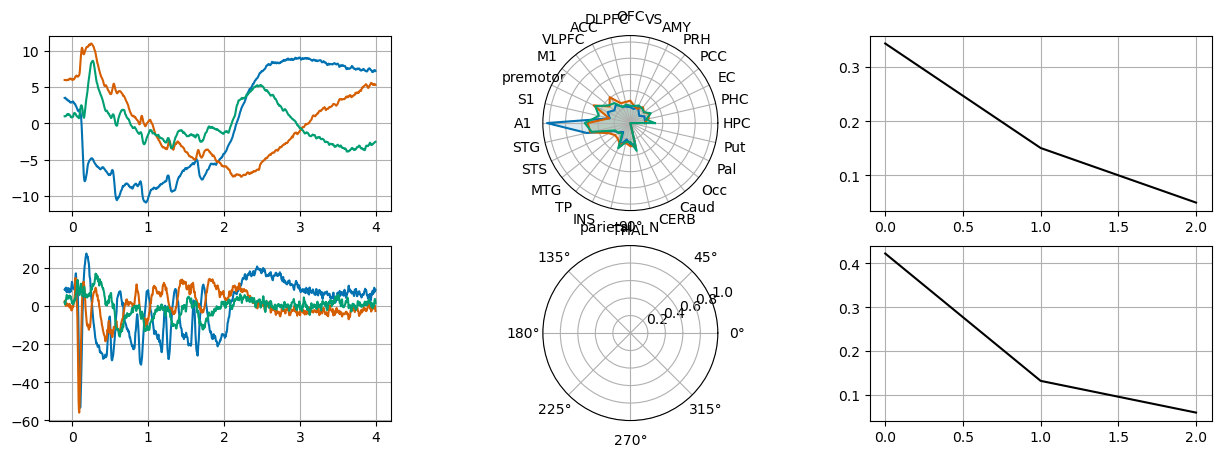

In [21]:
fig = plt.figure(figsize=(15, 5))
reg = [regions_ieeg, regions_meg]

for ipca, (x_trans, pca) in enumerate(zip([trans_ieeg, meg_trans], [ieeg_pca, pca_source])) :
    ax0 = fig.add_subplot(2, 3, 1+ipca*3)                  # Cartesian
    ax1 = fig.add_subplot(2, 3, 2+ipca*3, projection='polar')  # Polar
    ax2 = fig.add_subplot(2, 3, 3+ipca*3)                  # Cartesian

    for a in [ax0, ax2]:
        a.grid()

    for i in range(3):
        ax0.plot(time_ieeg, x_trans[ :, i], color=col_pc[i])
            
    ax2.plot(pca.explained_variance_ratio_, c='k')

    # Component weights by region
    df_compo = pd.DataFrame(np.abs(pca.components_.T),columns=[f'PC{i+1}' for i in range(3)])
    df_compo["region"] = reg[ipca]

    mean_ = (df_compo.groupby("region").mean().reindex(region_order, fill_value=0))
    angles = np.linspace(0, 2*np.pi, len(region_order), endpoint=False)
    angles = np.r_[angles, angles[0]]

    for i, col in enumerate(mean_.columns):
        values = np.r_[mean_[col].values, mean_[col].values[0]]
        ax1.plot(angles, values, label=col, color=col_pc[i])
        ax1.fill(angles, values, alpha=0.15, color=col_pc[i])

    ax1.set_xticks(angles[:-1])
    ax1.set_xticklabels(region_order, rotation=90)
    ax1.set_yticklabels([])
plt.tight_layout()

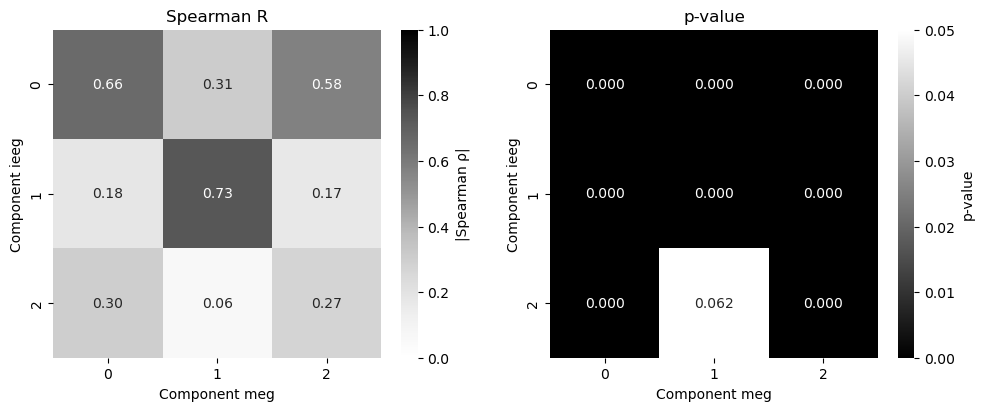

In [28]:
# 3. Compare TS
spearmr = np.zeros((3, 3))
speamp = np.zeros((3, 3))

for i in range(3):
    for j in range(3):
        spearmr[i, j], speamp[i, j] = spearmanr(trans_ieeg[:, i], meg_match_trans[:, j]) # meg_trans, trans_meg_concat, matched_avg_trans, meg_match_trans

fig, ax = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

sns.heatmap(abs(spearmr), ax=ax[0], cmap="Greys", vmin=0, vmax=1, annot=True, fmt=".2f", square=True, cbar_kws={"label": "|Spearman ρ|"})
sns.heatmap(speamp, ax=ax[1], cmap="grey", vmin=0, vmax=0.05, annot=True, fmt=".3f", square=True, cbar_kws={"label": "p-value"})

for a in ax:
    a.set_xlabel("Component meg")
    a.set_ylabel("Component ieeg")

ax[0].set_title("Spearman R")
ax[1].set_title("p-value")

plt.show()

In [71]:
df_label = pd.read_csv('out/labels_Kmean_singlePC3.csv')
np.unique(df_label['ieeg_pc2'])

array([0, 1, 2])

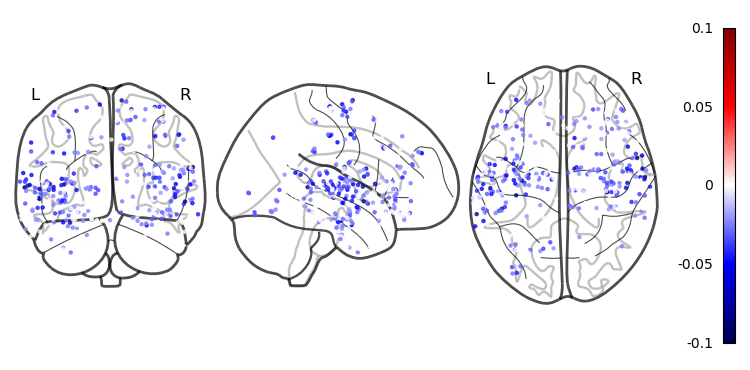

In [72]:
thr = CompoThr(ieeg_pca.components_).T
mask_thr=np.where(abs(thr[:,2]) >0, True, False)
mask_thr = np.where(df_label['ieeg_pc2'] == 1, True, False)
plotting.plot_markers(thr[mask_thr, 2], coord[mask_thr]*1000,node_cmap='seismic', node_size=5, node_vmin=-0.1, node_vmax=0.1)

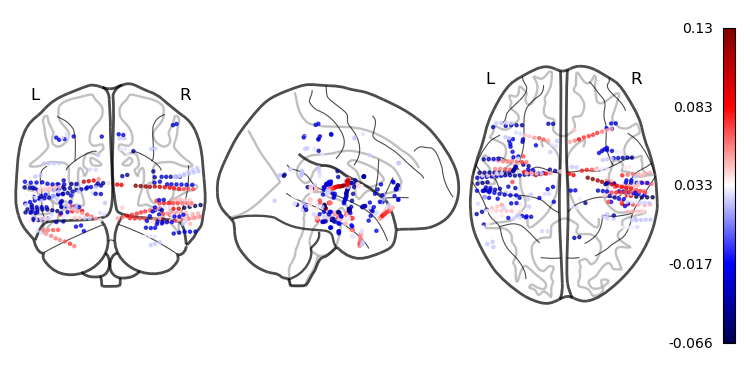

In [54]:
thr = CompoThr(pca_matched.components_).T
mask_thr=np.where(abs(thr[:, 2]) >0, True, False)
plotting.plot_markers(thr[mask_thr, 2], coord[mask_thr]*1000,node_cmap='seismic', node_size=5, node_vmin=-0.1, node_vmax=0.1)

## Compare subspace

In [68]:
V_ieeg = ieeg_pca.components_[:3].T   # (n_channels × 3)
V_meg  = pca_matched.components_[:3].T

angles = subspace_angles(V_ieeg, V_meg)
print("Principal angles (deg):", np.degrees(angles))
U, s, Vt = np.linalg.svd(V_ieeg.T @ V_meg)
print("Canonical correlations:", s)
similarity = np.sum(s**2) / len(s)
print("Similarity score:",similarity)

Principal angles (deg): [89.10175278 88.94026635 88.74844647]
Canonical correlations: [0.02184199 0.01849479 0.01567673]
Similarity score: 0.0003549632093238642


## Compare Covarriance

In [69]:
Sigma_ieeg = np.cov(ieeg_scaled.T, rowvar=False)
Sigma_meg  = np.cov(matched_scaled.T, rowvar=False)

mask = np.triu_indices_from(Sigma_ieeg, k=1)
rho, p = spearmanr(Sigma_ieeg[mask],Sigma_meg[mask])
print(rho, p)

def rv(A, B):
    return np.trace(A @ B) / np.sqrt(np.trace(A @ A) *np.trace(B @ B))
rv_coeff = rv(Sigma_ieeg, Sigma_meg)
print(rv_coeff)

-0.0010021179030216556 0.0679994784353755
0.00254647241592434


## Scaler

In [56]:
data_masked = mask_meg(meg_data_source, coord, radius_1=5, show=False)
data_masked = np.concat([data_masked[s, :, :,:] for s in range(data_masked.shape[0])], axis=1).mean(0) # concat subejct and mean condition 
data_matched = match_meg(meg_data_source, ieeg_subj_list, coord, meg_subj_list, subj_list).mean(0)
meg_data = np.concat([meg_data_source[s, :, :,:] for s in range(meg_data_source.shape[0])], axis=1).mean(0)

In [57]:
ieeg_data= ieeg_data_mean.mean(0)

In [58]:
# scaler the ieeg 
zero = np.argmin(abs(np.array(time_ieeg)))
mu = np.mean(ieeg_data[:, :zero], axis=1 , keepdims=True)
sigma = np.std(ieeg_data[:, :zero], axis=1, keepdims=True)
ieeg_scaled = (ieeg_data - mu)/sigma

# scaler the meg
mu = np.mean(meg_data[:, :zero], axis=1 , keepdims=True)
sigma = np.std(meg_data[:, :zero], axis=1, keepdims=True)
meg_scaled = (meg_data-mu)/sigma

In [30]:
pca_source = PCA(3)
meg_trans = pca_source.fit_transform(meg_data.T) 
pca_scaled = PCA(3)
meg_mask_trans = pca_scaled.fit_transform(meg_scaled.T) 

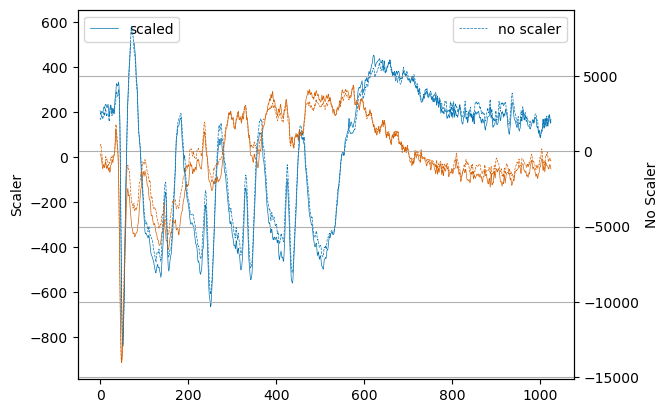

In [33]:
fig, ax=plt.subplots()
ax.plot(meg_mask_trans[:, 0], c=col_pc[0],label='scaled' , lw=0.5)
ax.plot(meg_mask_trans[:, 1], c=col_pc[1], lw=0.5)
ax.set_ylabel('Scaler')

axt = ax.twinx()
axt.plot(-meg_trans[:, 0],c=col_pc[0], ls='--', linewidth = 0.5, label='no scaler' )
axt.plot(-meg_trans[:, 1], c=col_pc[1],ls='--', linewidth = 0.5 )
axt.set_ylabel('No Scaler')
axt.legend()
ax.legend(loc = 'upper left')
plt.grid()